In [1]:
%reload_ext autoreload
%autoreload 2
from collections.abc import Iterable
import os
from pathlib import Path
import sys
from typing import Any, Optional

import matplotlib.pyplot as plt
from qecbench import TaskStats

import plot_utils

# Add parent directory to the path
sys.path.insert(0, os.path.abspath(".."))

from utils import get_csv_path

%matplotlib inline
plt.rcParams.update({"pdf.fonttype": 42})

In [2]:
def plot_iter_cdf(
    stats: Iterable[TaskStats],
    *,
    suptitle: str | None = None,
    save_at: str | Path | None = None,
):
    fig, ax = plt.subplots(figsize=(10, 3), layout="constrained")
    plot_utils.plot_iter_cdf(
        stats,
        ax,
        min_iter=100,
        label_fn=lambda s: s.metadata.decoder_name,
        xscale="log",
    )
    if suptitle:
        fig.suptitle(suptitle, fontsize=plot_utils.SUPTITLE_FONTSIZE)
    if save_at:
        fig.savefig(save_at, bbox_inches="tight")
    plt.show()

# BB_144_12_12_Circuit, basis=Z, rounds=12, error_rate=0.001

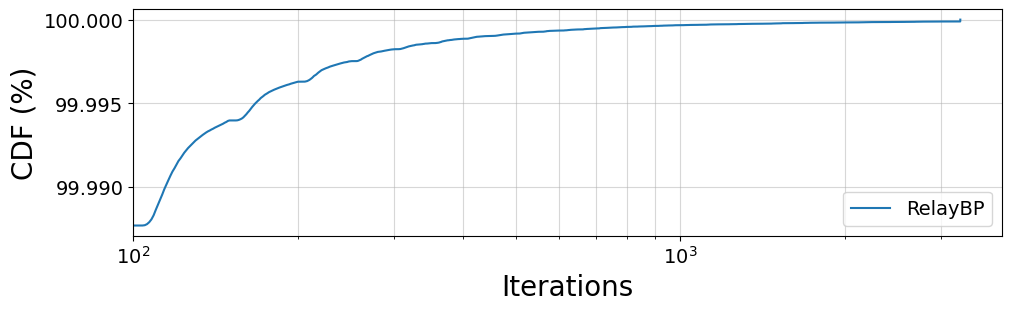

In [3]:
circuit_name = "BB_144_12_12_Circuit"
circuit_params = {"basis": "Z", "rounds": 12}
error_rate = 0.001

relaybp = {
    "gamma0": 0.2,
    "gamma_dist_interval": (-0.19806670996164882, 0.6200937872049607),
    "num_relays": 64,
    "pre_iter": 50,
    "max_iter_per_relay": 50,
    "stop_nconv": 1,
}

stats = plot_utils.load_stats(
    get_csv_path(circuit_name, circuit_params, "RelayBP"),
    error_rates=[error_rate],
    decoder_fixed_params=relaybp,
)

plot_iter_cdf(stats)


# RotatedSurfaceCode_Circuit, basis=Z, d=11, rounds=11, error_rate=0.001

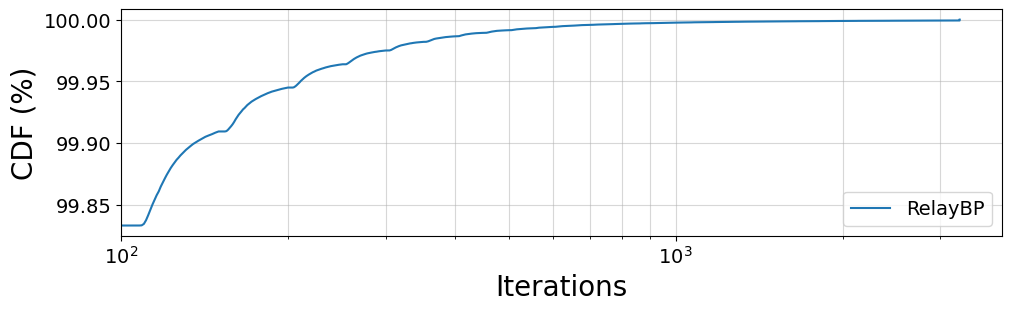

In [4]:
circuit_name = "RotatedSurfaceCode_Circuit"
circuit_params = {"basis": "Z", "d": 11, "rounds": 11}
error_rate = 0.001

bp = {"max_iter": 1000}
membp = {"max_iter": 1000, "gamma": 0.55}
relaybp = {
    "gamma0": 0.55,
    "gamma_dist_interval": (-0.2944735403909491, 0.9444054073490704),
    "num_relays": 64,
    "pre_iter": 50,
    "max_iter_per_relay": 50,
    "stop_nconv": 1,
}

stats = plot_utils.load_stats(
    get_csv_path(circuit_name, circuit_params, "RelayBP"),
    error_rates=[error_rate],
    decoder_fixed_params=relaybp,
)

plot_iter_cdf(stats)